In [2]:
import torch
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt

from get_dataset import GiMeFiveDataset
from variables import *

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(f"Using device: {device}")

Using device: mps


In [3]:
transform = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_dataset = GiMeFiveDataset(
    csv_file=dataset["train"]["labels"],
    img_dir=dataset["train"]["images"],
    transform=transform,
)
train_data_loader = DataLoader(
    train_dataset, batch_size=hyperparameters["batch_size"], shuffle=True, num_workers=4
)
train_image, train_label = next(iter(train_data_loader))
print(f"Train batch: image shape {train_image.shape}, labels shape {train_label.shape}")

Train batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])


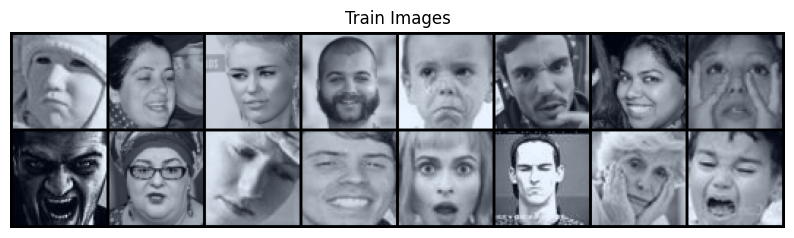

In [5]:
import matplotlib.pyplot as plt
import torchvision.utils

# Convert tensor images to a grid for visualization
grid_img = torchvision.utils.make_grid(train_image, nrow=8, normalize=True)

# Display the images
plt.figure(figsize=(10, 10))
plt.imshow(grid_img.permute(1, 2, 0))  # Convert from (C, H, W) to (H, W, C)
plt.title("Train Images")
plt.axis("off")  # Hide axis for better visualization
plt.show()